# Optimización Bayesiana
**Aprendizaje de Máquina - CEIA - FIUBA**

La idea central de la optimización bayesiana es aprender de evaluaciones previas para elegir el siguiente punto a probar.

Tiene dos componentes:
- un modelo probabilístico
- una función de adquisición

El algoritmo:
- Inicializa con X puntos (conjunto de hiperparámetros) aleatorios.
- Itera N veces: Explora y explota, evalúa la función objetivo y elige el mejor (o los mejores) parámetro(s) hasta el momento.
- Al final, devuelve la mejor combinación encontrada.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Dataset

default_df = pd.read_csv("./datasets/Default.csv")

default_df["default"] = default_df["default"].apply(lambda x: 1 if x == "Yes" else 0)
default_df["student"] = default_df["student"].apply(lambda x: 1 if x == "Yes" else 0)

default_df.head(20)

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879
5,0,1,919.588530,7491.558572
6,0,0,825.513331,24905.226578
7,0,1,808.667504,17600.451344
8,0,0,1161.057854,37468.529288
9,0,0,0.000000,29275.268293


In [3]:
# como siempre vamos separando nuestras variables predictoras de la variable a predecir
X = default_df.loc[:, ["balance", "income", "student"]].values
y = default_df.loc[:, "default"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
    random_state=0, stratify=y)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train) 
X_test = sc_x.transform(X_test)

print("Número de muestras:", X_train.shape[0])
print("Número de features:", X_train.shape[1])

Número de muestras: 7500
Número de features: 3


---
## Búsqueda bayesiana 1-D (K de KNN)

- Función objetivo: buscamos maximizar el *accuracy*.
- Modelo probabilístico: usamos un proceso gaussiano (GP).
- Función de adquisición: elegimos *Expected Improvement* (EI).

#### Función objetivo

Es la queremos maximizar. La función:
- recibe el hiperparámetro K
- crea un modelo KNN(k)
- calcula el score (el valor que queremos maximizar) como el accuracy promedio,usando validación cruzada 5-fold.

In [4]:
def knn_score_k(k):
    k = int(k)
    model = KNeighborsClassifier(n_neighbors=k)
    return np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy'))


#### Modelo probabilístico

Optamos por un [Proceso Gaussiano (GP)](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)

In [5]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=5.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
    random_state=42)

#### Función de adquisición

Elegimos *Expected Improvement* (EI).

In [6]:
def expected_improvement(x_candidates, gp, y_best, xi=0.01):

    mu, sigma = gp.predict(x_candidates, return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    sigma = np.maximum(sigma, 1e-9) # para evitar divisiones por cero

    improvement = mu - y_best - xi
    zz = improvement / sigma

    ei = improvement * norm.cdf(zz) + sigma * norm.pdf(zz)
    ei[sigma == 0.0] = 0.0
    return ei

#### Parámetros de búsqueda

In [7]:
K_range = np.arange(1, 51)          # dominio discreto
n_init = 5                          # puntos iniciales aleatorios
n_iter = 15                         # iteraciones del algoritmo

#### Puntos iniciales (exploración aleatoria)

- Se seleccionan n-init (5) valores aleatorios para los parámetros.
- Se evalúa la función objetivo (knn_score_k) en esos puntos.
- Estos son los primeros “puntos muestreados”, que sirven para construir un modelo inicial de la función objetivo.

In [8]:
rng = np.random.default_rng(42)
init_k = rng.choice(K_range, size=n_init, replace=False)
X_eval = np.array(init_k).reshape(-1,1).astype(float)
y_eval = np.array([knn_score_k(k) for k in init_k])

print(f'Valores iniciales elegidos para K: {init_k}')

Valores iniciales elegidos para K: [37 22 32  5 50]


#### Loop de optimización bayesiana

En cada iteración la búsqueda bayesiana 1D va ajustando el modelo probabilístico (GP) y eligiendo nuevos puntos según la función de adquisición (EI).

In [ ]:
for it in range(n_iter):
    # entrenamos GP con lo observado hasta ahora
    gp.fit(X_eval, y_eval)
    
    # candidato = todos los K no evaluados aún
    # Evaluamos sobre todo el rango para seleccionar el K con mayor EI
    candidates = np.array(K_range).reshape(-1,1).astype(float)
    
    # calculamos EI para cada candidato
    y_best = y_eval.max()
    ei = expected_improvement(candidates, gp, y_best, xi=0.01)
    
    # excluimos candidatos ya evaluados
    evaluated_set = set(X_eval.ravel().astype(int).tolist())
    ei_masked = ei.copy()
    for i, k in enumerate(candidates.ravel().astype(int)):
        if k in evaluated_set:
            ei_masked[i] = -np.inf
    
    # elegimos el K con mayor EI
    next_idx = int(np.argmax(ei_masked))
    K_next = int(candidates[next_idx,0])
    
    # evaluamos la función objetivo en K_next
    y_next = knn_score_k(K_next)
    
    # actualizamos datos
    X_eval = np.vstack([X_eval, [[K_next]]])
    y_eval = np.concatenate([y_eval, [y_next]])
    
    print(f"Iter {it+1:02d}: probando K={K_next} -> accuracy={y_next:.4f} (mejor "
        "hasta ahora = {y_eval.max():.4f})")

# Resultado final
best_idx = np.argmax(y_eval)
best_k = int(X_eval[best_idx,0])
best_score = y_eval[best_idx]
print("\nMejor K encontrado (1D):", best_k, "con accuracy:", best_score)

Iter 01: probando K=1 -> accuracy=0.9552 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 02: probando K=33 -> accuracy=0.9725 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 03: probando K=10 -> accuracy=0.9716 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 04: probando K=43 -> accuracy=0.9725 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 05: probando K=16 -> accuracy=0.9712 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 06: probando K=27 -> accuracy=0.9723 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 07: probando K=46 -> accuracy=0.9712 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 08: probando K=19 -> accuracy=0.9715 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 09: probando K=40 -> accuracy=0.9724 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 10: probando K=13 -> accuracy=0.9712 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 11: probando K=7 -> accuracy=0.9712 (mejor  hasta ahora = {y_eval.max():.4f})
Iter 12: probando K=25 -> accuracy=0.9719 (mejor  hasta ahora = {y_eval.max():

### Visualización

**Panel superior — Modelo (GP)**

- Curva azul: predicción del accuracy esperado (μ).
- Banda azul clara: incertidumbre del modelo (±1.96σ).
- Puntos rojos: valores realmente evaluados por cross-validation.
- Línea verde: mejor K observado.

**Panel inferior — Función de adquisición (EI)**
- Curva magenta: Expected Improvement (EI).

Picos altos de EI indican lugares prometedores para muestrear. Se busca un equilibrio entre alta predicción y alta incertidumbre.

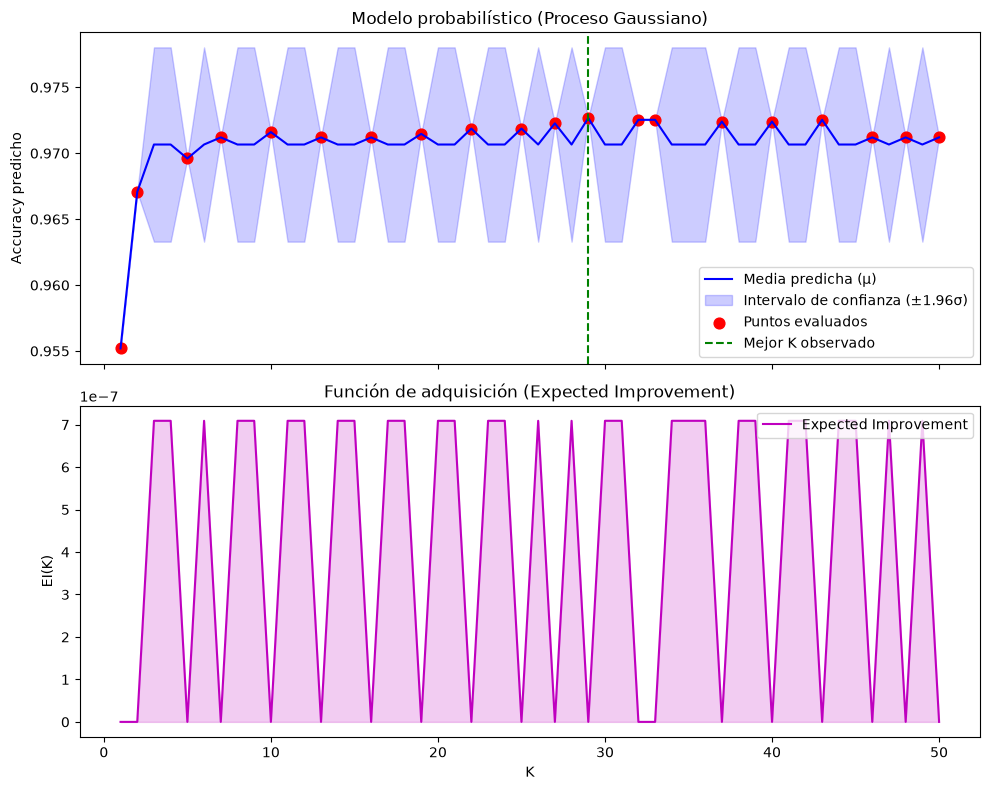

In [10]:
# Entrenamos el modelo final
gp.fit(X_eval, y_eval)
mu, sigma = gp.predict(K_range.reshape(-1,1), return_std=True)
ei = expected_improvement(K_range.reshape(-1,1), gp, y_eval.max(), xi=0.01)

fig, ax = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# 1) Modelo probabilístico (GP)
ax[0].plot(K_range, mu, 'b-', label='Media predicha (μ)')
ax[0].fill_between(K_range, mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2, color='blue', 
    label='Intervalo de confianza (±1.96σ)')
ax[0].scatter(X_eval, y_eval, c='red', s=60, label='Puntos evaluados')
ax[0].axvline(X_eval[np.argmax(y_eval)], color='green', linestyle='--', 
    label='Mejor K observado')
ax[0].set_ylabel("Accuracy predicho")
ax[0].set_title("Modelo probabilístico (Proceso Gaussiano)")
ax[0].legend(loc='lower right')

# 2) Función de adquisición (EI)
ax[1].plot(K_range, ei, 'm-', label='Expected Improvement')
ax[1].fill_between(K_range, 0, ei, color='m', alpha=0.2)
ax[1].set_xlabel("K")
ax[1].set_ylabel("EI(K)")
ax[1].set_title("Función de adquisición (Expected Improvement)")
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


---
## Búsqueda bayesiana para N parámetros

En este ejemplo vamos a buscar 3 parámetros:
- K (vecinos)
- pesos (uniforme o distancia)
- métrica (euclideana o manhattan)

Y definimos:
- Función objetivo: buscamos maximizar el *F1-score*.
- Modelo probabilístico: el mejor valor observado hasta ahora.
- Función de adquisición: seleccionar mejor + exploración ligera.


#### Hiperparámetros a optimizar

In [11]:
k_values = np.arange(1, 51)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

#### Función objetivo
- Recibe los hiperparámetros.
- Crea un modelo KNN con esos parámetros.
- Calcula el score (el valor que queremos maximizar) como el accuracy promedio, usando validación cruzada 5-fold.

In [12]:
def knn_score(params):
    model = KNeighborsClassifier(
        n_neighbors=int(params['K']),
        weights=params['weights'],
        metric=params['metric']
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    return np.mean(score)

#### Parámetros de búsqueda

In [13]:
n_init = 5     # puntos iniciales aleatorios
n_iter = 10    # iteraciones del algoritmo

#### Selección inicial de valores random (exploración)

- Se seleccionan n_init (5) valores aleatorios para los parámetros.
- Se evalúa la función objetivo (knn_score) en esos puntos.
- Estos son los primeros “puntos muestreados”, que sirven para construir un modelo inicial de la función objetivo.

In [14]:
# Lista para guardar resultados
evaluated_params = []
evaluated_scores = []

# Puntos iniciales (exploración)
np.random.seed(42)
for _ in range(n_init):  # puntos iniciales
    params = {
        'K': np.random.randint(1, 51),
        'weights': np.random.choice(weights_options),
        'metric': np.random.choice(metric_options)
    }
    score = knn_score(params)
    evaluated_params.append(params)
    evaluated_scores.append(score)

print('Valores iniciales elegidos para los hiper-parámetros:')
evaluated_params

Valores iniciales elegidos para los hiper-parámetros:


[{'K': 39, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')},
 {'K': 15, 'weights': np.str_('uniform'), 'metric': np.str_('manhattan')},
 {'K': 21, 'weights': np.str_('uniform'), 'metric': np.str_('manhattan')},
 {'K': 19, 'weights': np.str_('uniform'), 'metric': np.str_('euclidean')},
 {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')}]

#### Loop de optimización bayesiana

En cada iteración, la búsqueda va ajustando el modelo probabilístico y eligiendo nuevos puntos según la función de adquisición.

- Modelo: Es la lista de evaluaciones previas (evaluated_params y evaluated_scores) y la selección del mejor hasta ahora.
- Función de adquisición: decide dónde muestrear a continuación con una exploración ligera.

In [15]:
for i in range(n_iter):  # iteraciones
    
    # Elegimos el mejor parámetro hasta ahora (explotación)
    best_idx = np.argmax(evaluated_scores)
    best_params = evaluated_params[best_idx].copy()
    
    # Exploración ligera: modificamos un parámetro al azar
    param_to_change = np.random.choice(['K','weights','metric'])
    if param_to_change == 'K':
        best_params['K'] = np.random.randint(1, 51)
    elif param_to_change == 'weights':
        best_params['weights'] = np.random.choice(weights_options)
    else:
        best_params['metric'] = np.random.choice(metric_options)
    
    # Evaluamos nuevo conjunto
    score_new = knn_score(best_params)
    evaluated_params.append(best_params)
    evaluated_scores.append(score_new)
    
    print(f"Iteración {i+1}: {best_params} - F1-score={score_new:.4f}")

Iteración 1: {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('manhattan')} - F1-score=0.3853
Iteración 2: {'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3244
Iteración 3: {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3956
Iteración 4: {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3956
Iteración 5: {'K': 33, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3677
Iteración 6: {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3956
Iteración 7: {'K': 44, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3612
Iteración 8: {'K': 49, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3420
Iteración 9: {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.3956
Iteración 10: {'K': 11, 'weights': np.str_('distance'), 

#### Resultado final

- Buscamos el mejor score entre todos los puntos evaluados.
- Mostramos el K que maximiza la accuracy según nuestra búsqueda simulada.

In [16]:
best_idx = np.argmax(evaluated_scores)
print("\nMejor combinación encontrada:")
print(evaluated_params[best_idx])
print("con F1-score:", evaluated_scores[best_idx])


Mejor combinación encontrada:
{'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')}
con F1-score: 0.39560034523048226


### Visualización

Todos los valores utilizados para los hiper-parámetros: K, pesos y métrica de distancia.

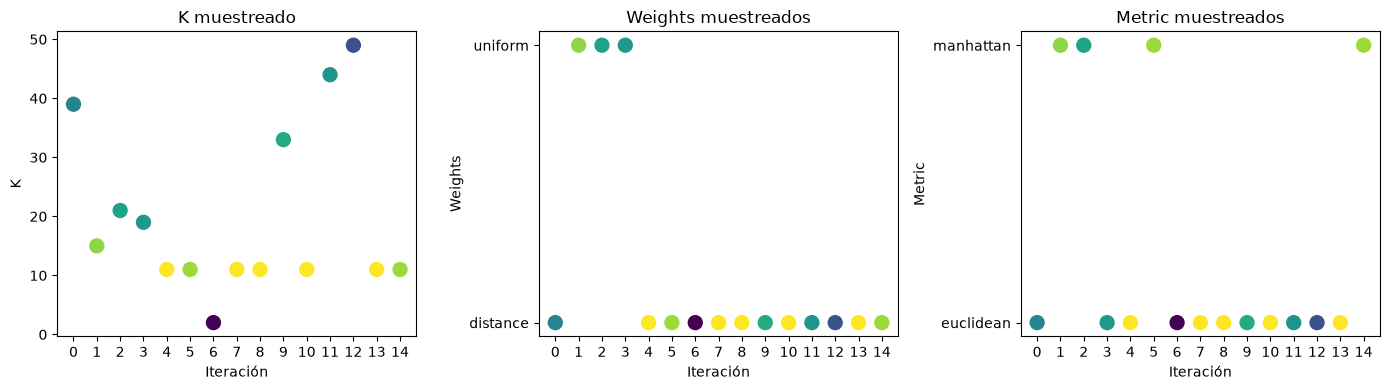

In [17]:
Ks = [p['K'] for p in evaluated_params]
weights = [p['weights'] for p in evaluated_params]
metrics = [p['metric'] for p in evaluated_params]

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.scatter(range(len(Ks)), Ks, c=evaluated_scores, cmap='viridis', s=100)
plt.xticks(range(len(Ks)))
plt.xlabel("Iteración")
plt.ylabel("K")
plt.title("K muestreado")

plt.subplot(1,3,2)
plt.scatter(range(len(weights)), weights, c=evaluated_scores, cmap='viridis', s=100)
plt.xticks(range(len(Ks)))
plt.xlabel("Iteración")
plt.ylabel("Weights")
plt.title("Weights muestreados")

plt.subplot(1,3,3)
plt.scatter(range(len(metrics)), metrics, c=evaluated_scores, cmap='viridis', s=100)
plt.xticks(range(len(Ks)))
plt.xlabel("Iteración")
plt.ylabel("Metric")
plt.title("Metric muestreados")

plt.tight_layout()
plt.show()


### Visualización

Evolución del F1-score. Modelo. Puntos evaluados.

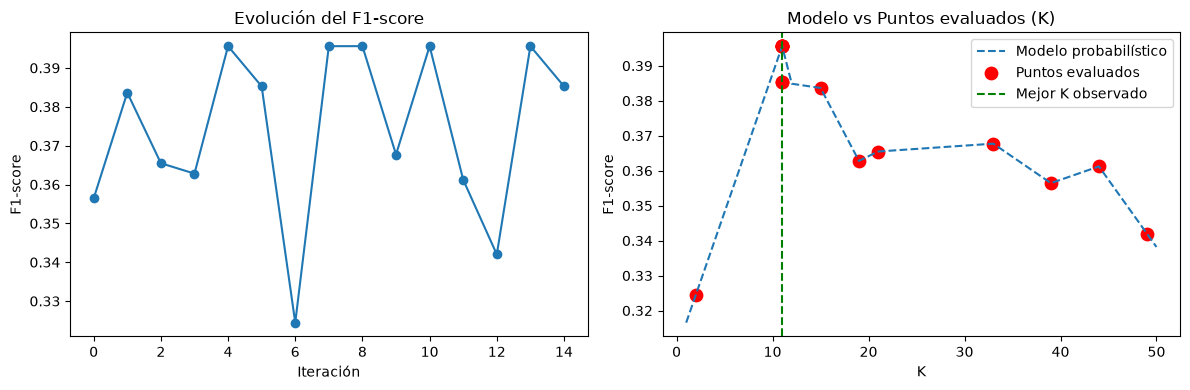

In [18]:
# Extraer valores de cada hiperparámetro
Ks = [p['K'] for p in evaluated_params]
weights = [p['weights'] for p in evaluated_params]
metrics = [p['metric'] for p in evaluated_params]

# Crear el "modelo probabilístico" para K (interpolación lineal)
K_range = np.arange(1, 51)
model = interp1d(Ks, evaluated_scores, kind='linear', fill_value="extrapolate")
pred_scores = model(K_range)

# Crear figura combinada
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Evolución del accuracy
axs[0].plot(evaluated_scores, marker='o')
axs[0].set_xlabel("Iteración")
axs[0].set_ylabel("F1-score")
axs[0].set_title("Evolución del F1-score")

# Modelo vs puntos evaluados (para K)
axs[1].plot(K_range, pred_scores, '--', label="Modelo probabilístico")
axs[1].scatter(Ks, evaluated_scores, c='red', label="Puntos evaluados", s=80)
axs[1].axvline(evaluated_params[best_idx]['K'], color='green', linestyle='--', 
    label='Mejor K observado')

axs[1].set_xlabel("K")
axs[1].set_ylabel("F1-score")
axs[1].set_title("Modelo vs Puntos evaluados (K)")
axs[1].legend()

plt.tight_layout()
plt.show()


### Entrenamiento y evaluación

In [19]:
# Obtenemos los mejores hiperparámetros encontrados
best_params = evaluated_params[best_idx]

# Creamos el modelo KNN con esos hiperparámetros
best_knn_bayesian = KNeighborsClassifier(
    n_neighbors=int(best_params['K']),
    weights=best_params['weights'],
    metric=best_params['metric']
)

# Entrenamos el modelo con todos los datos de entrenamiento
best_knn_bayesian.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",np.str_('distance')
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",np.str_('euclidean')
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str_[<U9](),np.str_('euclidean')


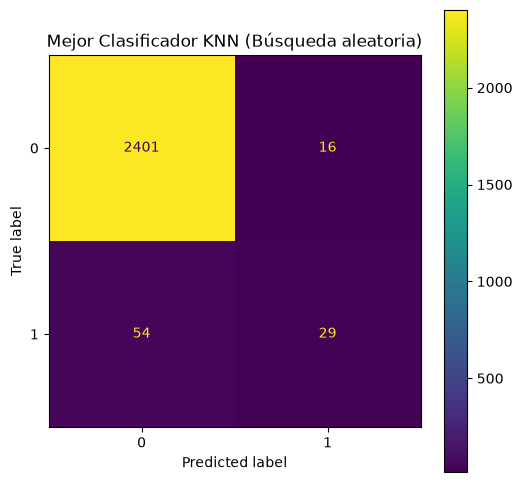

In [20]:
y_pred = best_knn_bayesian.predict(X_test)

cm_best_knn_grid_random = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best_knn_grid_random,
                              display_labels=best_knn_bayesian.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Mejor Clasificador KNN (Búsqueda aleatoria)");

In [21]:
# Predecimos sobre el conjunto de test
y_pred = best_knn_bayesian.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
# Suponiendo problema binario: cm = [[TN, FP], [FN, TP]]
TN, FP, FN, TP = cm.ravel()  

# Métricas
TPR = TP / (TP + FN)  # Sensibilidad / Recall
TNR = TN / (TN + FP)  # Especificidad
balanced_accuracy = (TPR + TNR) / 2
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Mostrar resultados
print("Mejor Clasificador KNN (Búsqueda Bayesiana)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad: {TNR:.4f}")
print(f"Exactitud balanceada: {balanced_accuracy:.4f}")
print(f"Precisión: {precision:.4f}")
print(f"Recuperación (Recall): {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Mejor Clasificador KNN (Búsqueda Bayesiana)
Sensibilidad (Recall): 0.3494
Especificidad: 0.9934
Exactitud balanceada: 0.6714
Precisión: 0.6444
Recuperación (Recall): 0.3494
F1-score: 0.4531
